In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
df.shape

(891, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df = df.drop("Cabin", axis=1)

In [8]:
df.isnull().sum()


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [9]:
"""# Titanic Dataset Summary

- The Titanic dataset contains 891 rows and 12 columns.
- Missing values were found in the Age, Cabin, and Embarked columns.
- The Cabin column had a large number of missing values, so it was removed.
- Missing values in the Age column were filled using the median, and Embarked was filled using the mode.
- The dataset contains both numerical and categorical features and is now ready for further preprocessing and machine learning."""

'# Titanic Dataset Summary\n\n- The Titanic dataset contains 891 rows and 12 columns.\n- Missing values were found in the Age, Cabin, and Embarked columns.\n- The Cabin column had a large number of missing values, so it was removed.\n- Missing values in the Age column were filled using the median, and Embarked was filled using the mode.\n- The dataset contains both numerical and categorical features and is now ready for further preprocessing and machine learning.'

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

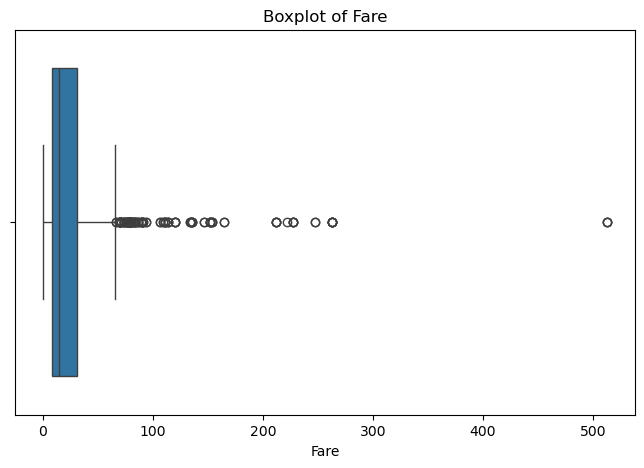

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Fare"])

plt.title("Boxplot of Fare")

plt.show()

In [12]:
"""### Outlier Detection

A boxplot was created for the Fare column.
    Several outliers were observed, indicating that a small number of passengers paid significantly higher ticket fares than the majority. 
    These values are expected because passengers traveled in different ticket classes."""

'### Outlier Detection\n\nA boxplot was created for the Fare column.\n    Several outliers were observed, indicating that a small number of passengers paid significantly higher ticket fares than the majority. \n    These values are expected because passengers traveled in different ticket classes.'

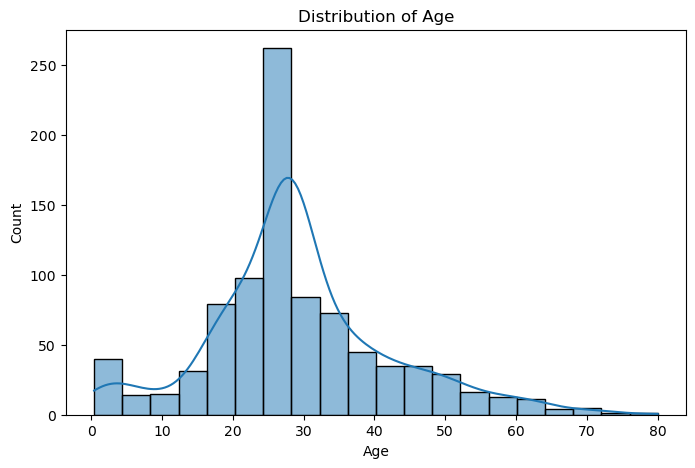

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Distribution of Age")

plt.xlabel("Age")

plt.ylabel("Count")

plt.show()

In [16]:
"""### Histogram Observation
The histogram shows that most passengers were between 20 and 35 years old. 
    The age distribution is right-skewed, with fewer older passengers. 
    Very young children and elderly passengers were less common in the dataset."""

'### Histogram Observation\nThe histogram shows that most passengers were between 20 and 35 years old. \n    The age distribution is right-skewed, with fewer older passengers. \n    Very young children and elderly passengers were less common in the dataset.'

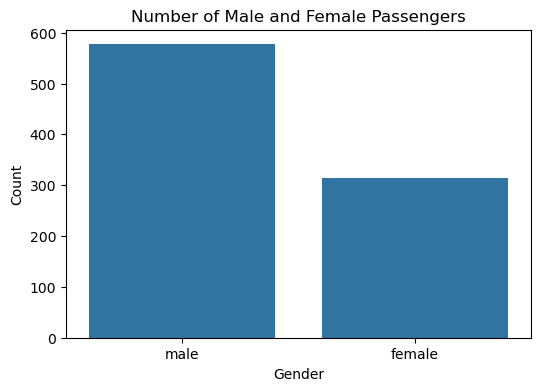

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x=df["Sex"])

plt.title("Number of Male and Female Passengers")

plt.xlabel("Gender")

plt.ylabel("Count")

plt.show()

In [14]:
"""Observation

- The number of male passengers is significantly higher than the number of female passengers.
- There are approximately 600 male passengers and around 300 female passengers in the dataset."""

'Observation\n\n- The number of male passengers is significantly higher than the number of female passengers.\n- There are approximately 600 male passengers and around 300 female passengers in the dataset.'

In [15]:
numeric_df = df.select_dtypes(include=["number"])

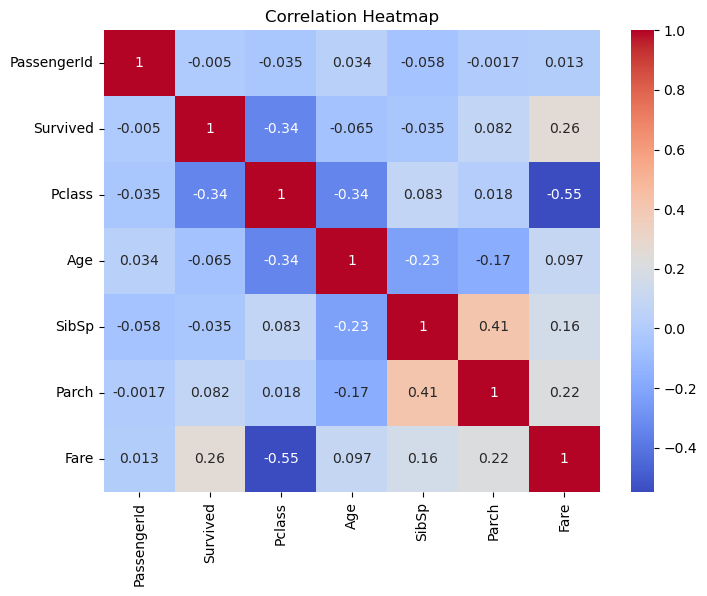

In [16]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [17]:
"""## Observations

- Missing values were found in the Cabin column and handled appropriately.
- Fare contains several outliers, but they were kept because they represent real passengers.
- Most passengers were between 20 and 35 years old.
- There were more male passengers than female passengers.
- Pclass shows the strongest relationship with survival, suggesting passenger class influenced survival chances."""

'## Observations\n\n- Missing values were found in the Cabin column and handled appropriately.\n- Fare contains several outliers, but they were kept because they represent real passengers.\n- Most passengers were between 20 and 35 years old.\n- There were more male passengers than female passengers.\n- Pclass shows the strongest relationship with survival, suggesting passenger class influenced survival chances.'

In [18]:
df = pd.get_dummies(
    df,
    columns=["Sex", "Embarked"],
    drop_first=True
)

In [19]:
df.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,True,False,True


In [20]:
df = df.drop(["Name", "Ticket"], axis=1)

In [21]:
df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,22.0,1,0,7.2500,True,False,True
1,2,1,1,38.0,1,0,71.2833,False,False,False
2,3,1,3,26.0,0,0,7.9250,False,False,True
3,4,1,1,35.0,1,0,53.1000,False,False,True
4,5,0,3,35.0,0,0,8.0500,True,False,True


In [22]:
X = df.drop("Survived", axis=1)

y = df["Survived"]

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
from sklearn.linear_model import LogisticRegression

In [26]:
model = LogisticRegression(max_iter=1000)

In [27]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [28]:
y_pred = model.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score

In [30]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8044692737430168


In [31]:
from sklearn.metrics import confusion_matrix

In [32]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[89 16]
 [19 55]]


In [33]:
"""The Logistic Regression model achieved an accuracy of 80.45%.

The confusion matrix shows that the model correctly predicted 89 passengers who did not survive and 55 passengers who survived.
It made 16 false positive predictions and 19 false negative predictions.
Overall, the model performs reasonably well and can correctly classify most passengers based on the available features."""

'The Logistic Regression model achieved an accuracy of 80.45%.\n\nThe confusion matrix shows that the model correctly predicted 89 passengers who did not survive and 55 passengers who survived.\nIt made 16 false positive predictions and 19 false negative predictions.\nOverall, the model performs reasonably well and can correctly classify most passengers based on the available features.'

In [34]:
from sklearn.datasets import fetch_california_housing

In [35]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame

In [36]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [37]:
features = [
    "MedInc",
    "HouseAge",
    "AveRooms",
    "Population",
    "AveOccup"
]

In [38]:
target = "MedHouseVal"

In [39]:
X = df[features]

y = df[target]

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [42]:
from sklearn.linear_model import LinearRegression

In [43]:
model = LinearRegression()

In [44]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [45]:
y_pred = model.predict(X_test)

In [46]:
from sklearn.metrics import mean_squared_error, r2_score

In [47]:
rmse = mean_squared_error(y_test, y_pred) ** 0.5

r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 0.8100228004441534
R2 Score: 0.4992884296930026


In [48]:
"""The R² score of 0.499 means that the model can explain about 50% of the variation in house prices using the selected features.
This shows that the model has learned some important patterns from the data, but there are still other factors affecting house prices that were not included.
A higher R² score would indicate better predictions. 
Overall, the model provides a reasonable starting point for predicting house values."""


'The R² score of 0.499 means that the model can explain about 50% of the variation in house prices using the selected features.\nThis shows that the model has learned some important patterns from the data, but there are still other factors affecting house prices that were not included.\nA higher R² score would indicate better predictions. \nOverall, the model provides a reasonable starting point for predicting house values.'

In [49]:
import matplotlib.pyplot as plt

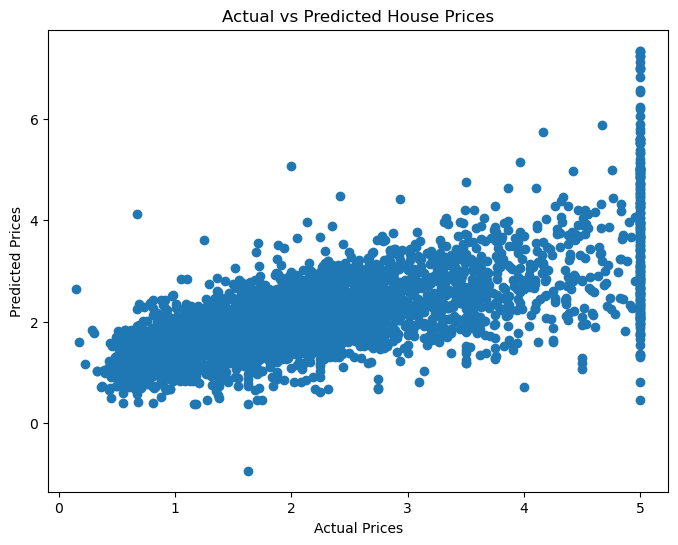

In [50]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()

In [51]:
"""The scatter plot shows a positive relationship between actual and predicted house prices.
    As the actual price increases, the predicted price generally increases as well.
    However, the points are somewhat spread out, indicating that the model is not perfectly accurate and there is room for improvement."""


'The scatter plot shows a positive relationship between actual and predicted house prices.\n    As the actual price increases, the predicted price generally increases as well.\n    However, the points are somewhat spread out, indicating that the model is not perfectly accurate and there is room for improvement.'

In [52]:
import pandas as pd

titanic_df = pd.read_csv("train.csv")

In [53]:
print(titanic_df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [54]:
titanic_df = titanic_df.drop("Cabin", axis=1)

In [55]:
titanic_df["Age"] = titanic_df["Age"].fillna(titanic_df["Age"].median())

In [56]:
titanic_df["Embarked"] = titanic_df["Embarked"].fillna(titanic_df["Embarked"].mode()[0])

In [57]:
titanic_df = titanic_df.drop(["Name", "Ticket"], axis=1)

In [58]:
titanic_df = pd.get_dummies(
    titanic_df,
    columns=["Sex", "Embarked"],
    drop_first=True
)

In [59]:
X = titanic_df.drop("Survived", axis=1)
y = titanic_df["Survived"]

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [61]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [62]:
y_pred = model.predict(X_test)

In [63]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.85      0.84       105
           1       0.77      0.74      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179



In [64]:
from sklearn.model_selection import GridSearchCV

In [65]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

In [66]:
grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='accuracy'
)

In [67]:
grid.fit(X_train, y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

,estimator,LogisticRegre...max_iter=1000)
,param_grid,"{'C': [0.01, 0.1, ...], 'solver': ['liblinear', 'lbfgs']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [68]:
print(grid.best_params_)

{'C': 1, 'solver': 'liblinear'}


In [69]:
best_model = grid.best_estimator_

In [70]:
y_pred_tuned = best_model.predict(X_test)

In [71]:
from sklearn.metrics import accuracy_score

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

print("Original Accuracy:", accuracy)
print("Tuned Accuracy:", tuned_accuracy)

Original Accuracy: 0.8044692737430168
Tuned Accuracy: 0.7988826815642458


In [72]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [73]:
print(df.shape)
print(df.info())

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

In [74]:
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [75]:
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [76]:
print(df.isnull().sum().sort_values(ascending=False).head(10))

customerID          0
DeviceProtection    0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
TechSupport         0
dtype: int64


In [77]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [78]:
df = df.dropna()

In [79]:
print(pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665


In [80]:
print(df.groupby("Churn")["tenure"].mean())

Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64


In [81]:
print(df.groupby("Churn")["MonthlyCharges"].mean())

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64


In [82]:
X = df.drop(["Churn", "customerID"], axis=1)
y = df["Churn"].map({"Yes": 1, "No": 0})

In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [84]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_cols = X.select_dtypes(include="object").columns
numeric_cols = X.select_dtypes(exclude="object").columns

In [85]:
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", StandardScaler(), numeric_cols)
])

In [86]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

In [87]:
logistic_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [88]:
from sklearn.tree import DecisionTreeClassifier

tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        random_state=42,
        class_weight="balanced"
    ))
])

In [89]:
tree_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [90]:
from sklearn.metrics import accuracy_score, classification_report

log_pred = logistic_model.predict(X_test)
tree_pred = tree_model.predict(X_test)

In [91]:
print("Logistic Regression")
print(classification_report(y_test, log_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [92]:
print("Decision Tree")
print(classification_report(y_test, tree_pred))

Decision Tree
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



In [93]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, tree_pred))

Logistic Regression Accuracy: 0.7256574271499645
Decision Tree Accuracy: 0.7334754797441365


In [94]:
feature_names = tree_model.named_steps["preprocessor"].get_feature_names_out()

In [95]:
importances = tree_model.named_steps["model"].feature_importances_

In [96]:
feature_importance = pd.Series(
    importances,
    index=feature_names
).sort_values(ascending=False)

In [97]:
print(feature_importance.head(3))

cat__Contract_Month-to-month        0.615233
num__tenure                         0.109974
cat__InternetService_Fiber optic    0.098550
dtype: float64


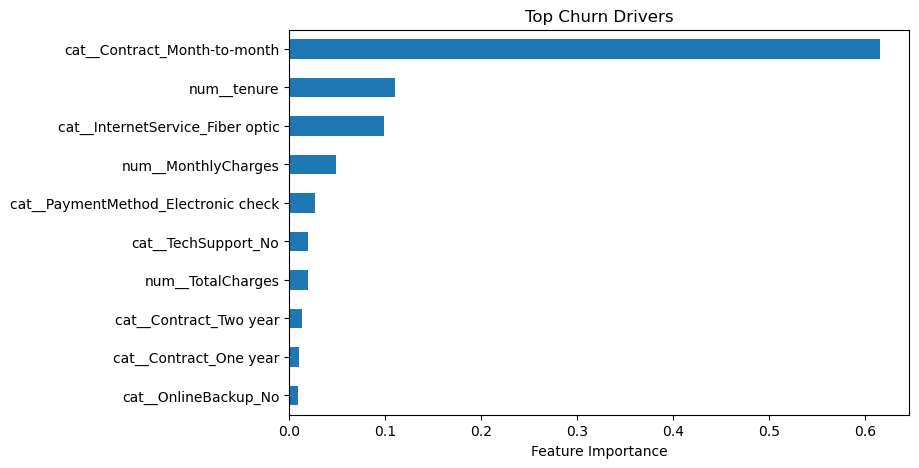

In [98]:
import matplotlib.pyplot as plt

feature_importance.head(10).sort_values().plot(kind="barh", figsize=(8,5))

plt.title("Top Churn Drivers")
plt.xlabel("Feature Importance")
plt.show()

In [99]:
print("""
Business Summary:
Customers on month-to-month contracts appear to be the biggest churn risk.
Shorter-tenure customers are also more likely to leave, suggesting that early customer retention is important.
Fiber optic customers show a noticeable contribution to churn in our model.
The company could focus on longer-term contracts, early retention offers, and better support for high-risk customers.
These findings can help the business identify customers who may leave and take action before they churn.
""")


Business Summary:
Customers on month-to-month contracts appear to be the biggest churn risk.
Shorter-tenure customers are also more likely to leave, suggesting that early customer retention is important.
Fiber optic customers show a noticeable contribution to churn in our model.
The company could focus on longer-term contracts, early retention offers, and better support for high-risk customers.
These findings can help the business identify customers who may leave and take action before they churn.

